<a href="https://colab.research.google.com/github/Hugo-Mendonca/Visao-Computacional-para-identifica-o-de-tumor-cerebral/blob/main/Projeto_de_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto da cadeira de Inteligência artificial

##Estudo do dataset

###Importação das blibliotécas

In [ ]:
#Sistma e manipulação de arquivo
import os
import random
from tqdm import tqdm
from google.colab import files
import yaml
import shutil

#Processamento de dados e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

#Core do pytorch e redes neurais[import torch]
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#Visão computacional(torchvision)
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler


#métricas e avaliação
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

###Funções usada na EDA

####Função para coletar as dimensões das imagens

In [ ]:
def collect_image_dimensions(base_dir):
    widths = []
    heights = []
    aspect_ratios = []
    image_paths = []
    type_file = []

    # percorre pecorrer dentro das pastas para achar todas as imagens
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_paths.append(os.path.join(root, file))

    print(f"Coletando dimensões para {len(image_paths)} imagens em {base_dir}...")

    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                image_type = img.format
                type_file.append(image_type)
                width, height = img.size
                widths.append(width)
                heights.append(height)
                aspect_ratios.append(width / height)
        except Exception as e:
            print(f"Não foi possível abrir ou processar a imagem {img_path}: {e}")

    return widths, heights, aspect_ratios, type_file


####Função para calcular métricas de cor,brilho, contraste e dimensões de uma imagem

In [ ]:
def calculate_image_metrics(image_path):
    try:
        with Image.open(image_path) as img:
            image_type = img.format
            width, height = img.size


            return  width, height

    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        return None, None, None, None, None, None, None


####Função para detectar outliers usando o método dos Inter quartis

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound



####Função para dispor as imagens em um grid

In [ ]:
def display_image_grid(image_paths, title, rows, cols):
    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(image_paths):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


###Análise Exploratória dos Dados (EDA)


#### 1. Fazer Upload do Arquivo .zip



In [ ]:
print("Por favor, selecione o arquivo .zip do seu dataset para upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('Arquivo "{name}" com tamanho {length} bytes foi carregado com sucesso.'.format(
      name=fn, length=len(uploaded[fn])))


Por favor, selecione o arquivo .zip do seu dataset para upload:


Saving Projeto IA.zip to Projeto IA.zip
Arquivo "Projeto IA.zip" com tamanho 311417066 bytes foi carregado com sucesso.


#### 2. Descompactar o Dataset

Agora, vamos descompactar o arquivo `.zip`. Certifique-se de substituir `nome_do_seu_dataset.zip` pelo nome real do arquivo que você carregou.

In [ ]:
zip_file_name = list(uploaded.keys())[0]

# Criar uma pasta para o dataset descompactado
# O nome da pasta será o nome do arquivo zip (sem a extensão .zip)
dataset_name = os.path.splitext(zip_file_name)[0]
if not os.path.exists(dataset_name):
    os.makedirs(dataset_name)

# Descompactar o arquivo
!unzip -q "{zip_file_name}" -d "{dataset_name}"

print(f"Dataset '{zip_file_name}' descompactado para a pasta '{dataset_name}'.")
print("Verificando a estrutura de pastas:")
!ls -R "{dataset_name}" # Lista recursivamente o conteúdo da pasta


A saída de streaming foi truncada nas últimas 5000 linhas.
1665_jpg.rf.182cb67d6d5a498e549f3939c34f449f.jpg
1666_jpg.rf.991901328dc6db11613da1b8e7bc7838.jpg
1667_jpg.rf.91e266e0f36ee9588df149edee45075b.jpg
1668_jpg.rf.d06e92df9cf856ea615a38a18b192314.jpg
1669_jpg.rf.d5050d3583e5bff720439f2b0ccf75d8.jpg
166_jpg.rf.0cd6c4709e0bb0cf2d1d5e667d1ad25d.jpg
1670_jpg.rf.300ad3bfa0c2bf33109dc0f61da1c850.jpg
1671_jpg.rf.e7a9302c16652c474c49f3a99b658c8f.jpg
1673_jpg.rf.3ec35074a612e4a4209a906d7ad8680d.jpg
1674_jpg.rf.bb913e8b9417c6182f7c417924bae355.jpg
1675_jpg.rf.f75622fcc94ad3c8d29b9140db225bbe.jpg
1676_jpg.rf.d0592d27450db3cd0e5d71be459920df.jpg
1677_jpg.rf.96f54c38e4dbbc50f80415cb7ec14fc2.jpg
1678_jpg.rf.a97d94de1f6a409a703e963af8c53794.jpg
1679_jpg.rf.4f0aada89da259641382cfdae65f1c13.jpg
1682_jpg.rf.5532342f38cc6712df034338398f44d0.jpg
1683_jpg.rf.78f6a6a312040c5e843bdf465d329f2b.jpg
1684_jpg.rf.352e50336cf9b3f8c49bc6140743b379.jpg
1686_jpg.rf.867500364afcd839df96fc4a2d7aea92.jpg
1688_jpg.rf

#### 3. Carregar o Dataset Usando `torchvision.datasets.ImageFolder`

Vamos definir as transformações e carregar os datasets de treino e teste.

##### 3.1 Análise Geométrica das Imagens Originais

Antes de aplicar quaisquer transformações, vamos analisar as dimensões originais das imagens no dataset para entender a distribuição de largura, altura e proporção. Isso nos ajudará a tomar decisões informadas sobre as transformações de `resize` e `crop`.

Ainda estamos com problemas para localizar os arquivos de imagem. Para identificar o caminho correto, vamos listar o conteúdo completo do diretório `archive` para entender a estrutura de pastas.


In [ ]:
print('Listando o conteúdo completo do diretório do dataset:')
!ls -R {dataset_name}

Listando o conteúdo completo do diretório do dataset:
ls: cannot access 'Projeto': No such file or directory
ls: cannot access 'IA': No such file or directory


In [ ]:
# Define o caminho para as pastas de treino e teste dentro do dataset descompactado
# As variáveis dataset_name já estão definidas do passo anterior.
train_dir_full_path = os.path.join(dataset_name, 'BrainTumor', 'BrainTumorYolov11', 'train', 'images') # Adjusting path based on 'ls -R' output
valid_dir_full_path = os.path.join(dataset_name, 'BrainTumor', 'BrainTumorYolov11', 'valid', 'images') # Adjusting path based on 'ls -R' output
test_dir_full_path = os.path.join(dataset_name, 'BrainTumor', 'BrainTumorYolov11', 'test', 'images') # Adjusting path based on 'ls -R' output

# Coleta as dimensões do dataset de treino
train_widths, train_heights, train_aspect_ratios,train_file_type = collect_image_dimensions(train_dir_full_path)

#Coleta as dimensões do dataset de treino
valid_widths, valid_heights, valid_aspect_ratios,valid_file_type = collect_image_dimensions(valid_dir_full_path)

# Coleta as dimensões do dataset de teste
test_widths, test_heights, test_aspect_ratios, test_file_type = collect_image_dimensions(test_dir_full_path)

# Combina as dimensões para uma análise geral
all_widths = train_widths + test_widths + valid_widths
all_heights = train_heights + test_heights + valid_heights
all_aspect_ratios = train_aspect_ratios + test_aspect_ratios + valid_aspect_ratios

print(f"\nTotal de imagens analisadas: {len(all_widths)}")
if len(all_widths) > 0:
  print("Estatísticas de Largura:")
  print(f"  Mínima: {np.min(all_widths)}, Máxima: {np.max(all_widths)}, Média: {np.mean(all_widths):.2f}, Mediana: {np.median(all_widths)}")
  print("Estatísticas de Altura:")
  print(f"  Mínima: {np.min(all_heights)}, Máxima: {np.max(all_heights)}, Média: {np.mean(all_heights):.2f}, Mediana: {np.median(all_heights)}")
  print("Estatísticas de Proporção (Largura/Altura):")
  print(f"  Mínima: {np.min(all_aspect_ratios):.2f}, Máxima: {np.max(all_aspect_ratios):.2f}, Média: {np.mean(all_aspect_ratios):.2f}, Mediana: {np.median(all_aspect_ratios):.2f}")
else:
  print("Nenhuma imagem encontrada nos diretórios especificados para análise.")

Coletando dimensões para 2144 imagens em Projeto IA/BrainTumor/BrainTumorYolov11/train/images...
Coletando dimensões para 612 imagens em Projeto IA/BrainTumor/BrainTumorYolov11/valid/images...
Coletando dimensões para 308 imagens em Projeto IA/BrainTumor/BrainTumorYolov11/test/images...

Total de imagens analisadas: 3064
Estatísticas de Largura:
  Mínima: 640, Máxima: 640, Média: 640.00, Mediana: 640.0
Estatísticas de Altura:
  Mínima: 640, Máxima: 640, Média: 640.00, Mediana: 640.0
Estatísticas de Proporção (Largura/Altura):
  Mínima: 1.00, Máxima: 1.00, Média: 1.00, Mediana: 1.00


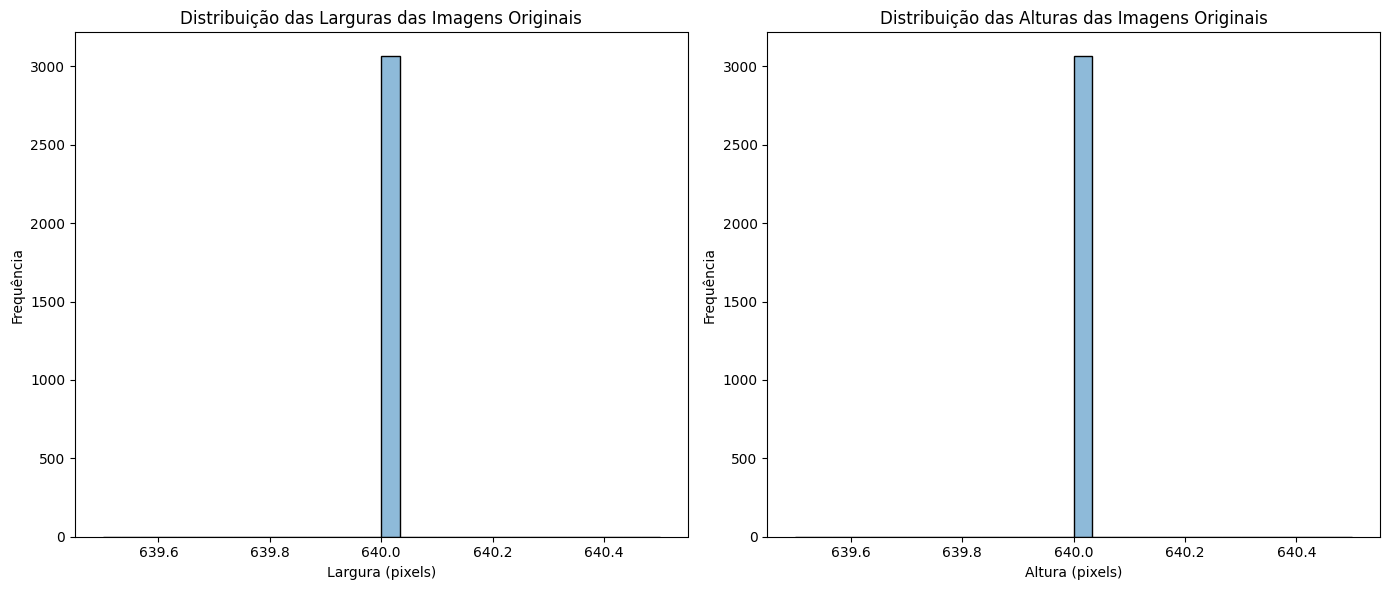

In [ ]:
# Plota histogramas para Largura e Altura
if len(all_widths) > 0:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
    sns.histplot(all_widths, bins=30, kde=True)
    plt.title('Distribuição das Larguras das Imagens Originais')
    plt.xlabel('Largura (pixels)')
    plt.ylabel('Frequência')

    plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
    sns.histplot(all_heights, bins=30, kde=True)
    plt.title('Distribuição das Alturas das Imagens Originais')
    plt.xlabel('Altura (pixels)')
    plt.ylabel('Frequência')

    plt.tight_layout()
    plt.show()
else:
    print("Não há dados de largura e altura para plotar os histogramas.")

##### 3.2 Reorganizando o Dataset para `ImageFolder`

Como o dataset atual está formatado para YOLO (com todas as imagens em uma pasta `images` e rótulos em `labels` separados), a função `torchvision.datasets.ImageFolder` não consegue encontrar as classes. Precisamos criar uma nova estrutura de pastas onde cada imagem esteja em uma subpasta com o nome de sua classe. O script abaixo fará isso:

1.  Lerá o arquivo `data.yaml` para obter os nomes das classes.
2.  Criará novas pastas para treino, validação e teste, e dentro delas, subpastas para cada classe (ex: `archive/classification_ready/train/glioma/`).
3.  Copiará cada imagem para a pasta da classe correspondente, usando as informações dos arquivos de rótulo (`.txt`).

In [ ]:
# Define o caminho base do dataset YOLO
yolo_base_path = os.path.join(dataset_name, 'BrainTumor', 'BrainTumorYolov11')
data_yaml_path = os.path.join(yolo_base_path, 'data.yaml')

print(f"Procurando data.yaml em: {data_yaml_path}")

# Carrega os nomes das classes do arquivo data.yaml
try:
    with open(data_yaml_path, 'r') as f:
        yolo_data = yaml.safe_load(f)
    class_names = yolo_data.get('names', []) # Usa .get para evitar KeyError se 'names' não existir
    if class_names:
        print(f"Classes encontradas no data.yaml: {class_names}")
    else:
        print("Aviso: 'names' key encontrada no data.yaml, mas a lista de classes está vazia.")
except FileNotFoundError:
    print(f"Erro: data.yaml não encontrado em {data_yaml_path}. Verifique o caminho.")
    class_names = []
except Exception as e:
    print(f"Erro ao carregar data.yaml: {e}")
    class_names = []

# Define o caminho base para a nova estrutura compatível com ImageFolder
imagefolder_base_path = os.path.join(dataset_name, 'classification_ready')
os.makedirs(imagefolder_base_path, exist_ok=True)
print(f"Estrutura para ImageFolder será criada em: {imagefolder_base_path}")

# Processa os conjuntos de treino, validação e teste
# Define as variáveis que serão usadas na célula 4cbb55e2
imagefolder_train_path = os.path.join(imagefolder_base_path, 'train')
imagefolder_valid_path = os.path.join(imagefolder_base_path, 'valid')
imagefolder_test_path = os.path.join(imagefolder_base_path, 'test')

if class_names:
    for subset in ['train', 'valid', 'test']:
        src_images_dir = os.path.join(yolo_base_path, subset, 'images')
        src_labels_dir = os.path.join(yolo_base_path, subset, 'labels')
        dest_subset_dir = os.path.join(imagefolder_base_path, subset)
        os.makedirs(dest_subset_dir, exist_ok=True)

        print(f"\nProcessando subset: {subset}...")
        if not os.path.exists(src_images_dir):
            print(f"Aviso: Diretório de imagens não encontrado para {subset} em {src_images_dir}. Pulando.")
            continue

        images_copied_count = 0
        for class_name in class_names:
            os.makedirs(os.path.join(dest_subset_dir, class_name), exist_ok=True)

        for img_file in os.listdir(src_images_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_name_without_ext = os.path.splitext(img_file)[0]
                label_file = os.path.join(src_labels_dir, img_name_without_ext + '.txt')

                if os.path.exists(label_file):
                    with open(label_file, 'r') as f:
                        first_line = f.readline().strip()
                        if first_line:
                            try:
                                class_id = int(first_line.split(' ')[0])
                                if 0 <= class_id < len(class_names):
                                    class_name = class_names[class_id]

                                    src_img_path = os.path.join(src_images_dir, img_file)
                                    dest_img_path = os.path.join(dest_subset_dir, class_name, img_file)
                                    shutil.copy(src_img_path, dest_img_path)
                                    images_copied_count += 1
                                else:
                                    # print(f"Aviso: ID de classe inválido {class_id} para {img_file}. Pulando.") # Descomentar para depurar IDs inválidos
                                    pass
                            except ValueError:
                                # print(f"Aviso: Formato de label inválido para {img_file}. Pulando.") # Descomentar para depurar formatos inválidos
                                pass
                        else:
                            # print(f"Aviso: Arquivo de label vazio para {img_file}. Pulando.") # Descomentar para depurar labels vazios
                            pass
                else:
                    # print(f"Aviso: Arquivo de label não encontrado para {img_file}. Pulando.") # Descomentar para depurar labels ausentes
                    pass
        print(f"  {images_copied_count} imagens copiadas para {subset}.")

    print(f"\nDataset reorganizado com sucesso para {imagefolder_base_path}")
else:
    print("Não foi possível reorganizar o dataset: Nomes das classes não encontrados ou vazios.")


Procurando data.yaml em: Projeto IA/BrainTumor/BrainTumorYolov11/data.yaml
Classes encontradas no data.yaml: ['glioma', 'meningioma', 'pituitary']
Estrutura para ImageFolder será criada em: Projeto IA/classification_ready

Processando subset: train...
  2144 imagens copiadas para train.

Processando subset: valid...
  612 imagens copiadas para valid.

Processando subset: test...
  308 imagens copiadas para test.

Dataset reorganizado com sucesso para Projeto IA/classification_ready


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Aumenta o dataset horizontalmente
    transforms.ToTensor(), # Converte a imagem para um tensor PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normaliza
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_valid = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Carrega os datasets usando ImageFolder
try:
    train_dataset = datasets.ImageFolder(imagefolder_train_path, transform=transform_train)
    test_dataset = datasets.ImageFolder(imagefolder_test_path, transform=transform_test)
    valid_dataset = datasets.ImageFolder(imagefolder_valid_path, transform=transform_valid)

    print(f"Número de imagens de treino: {len(train_dataset)}")
    print(f"Número de imagens de teste: {len(test_dataset)}")
    print(f"Classes encontradas: {train_dataset.classes}")

    # Cria DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    print(f"\nPrimeiro batch do DataLoader de treino: {next(iter(train_loader))[0].shape}")

except Exception as e:
    print(f"Erro ao carregar o dataset com ImageFolder: {e}")
    print("Verifique se a estrutura de pastas está correta (ex: seu_dataset/dataset_processed/train/classe1/img.jpg).")
    print("Caminho do diretório de treino esperado:", imagefolder_train_path)
    print("Caminho do diretório de teste esperado:", imagefolder_test_path)
    print("Caminho do diretório de validação esperado:", imagefolder_valid_path)

Número de imagens de treino: 2144
Número de imagens de teste: 308
Classes encontradas: ['glioma', 'meningioma', 'pituitary']

Primeiro batch do DataLoader de treino: torch.Size([32, 3, 640, 640])


In [ ]:
# Lista para armazenar os dados das métricas
metrics_data = []

# Função auxiliar para processar um dataset e coletar métricas
def process_dataset_for_metrics(dataset, subset_name):
    print(f"Coletando métricas para o conjunto {subset_name} ({len(dataset)} imagens)...")
    if len(dataset) == 0:
        print(f"  Dataset {subset_name} está vazio, pulando coleta de métricas.")
        return

    for i in tqdm(range(len(dataset)), desc=f"Processando {subset_name}"):
        img_path, class_id = dataset.samples[i]
        class_name = dataset.classes[class_id]
        width, height = calculate_image_metrics(img_path) # Usando a função previamente definida
        metrics_data.append({
            'path': img_path,
            'class': class_name,
            'width': width,
            'height': height,
            'subset': subset_name # Adicionar a qual subset a imagem pertence
        })
    print(f"  Métricas coletadas para {len(dataset)} imagens no conjunto {subset_name}.")

# Processar os três datasets
if 'train_dataset' in locals() and train_dataset:
    process_dataset_for_metrics(train_dataset, 'train')
else:
    print("train_dataset não encontrado ou é None/vazio.")

if 'valid_dataset' in locals() and valid_dataset:
    process_dataset_for_metrics(valid_dataset, 'valid')
else:
    print("valid_dataset não encontrado ou é None/vazio.")

if 'test_dataset' in locals() and test_dataset:
    process_dataset_for_metrics(test_dataset, 'test')
else:
    print("test_dataset não encontrado ou é None/vazio.")

# Criar o DataFrame final
metrics_df = pd.DataFrame(metrics_data)

print(f"\nDataFrame 'metrics_df' criado com {len(metrics_df)} entradas.")
display(metrics_df.head())

Coletando métricas para o conjunto train (2144 imagens)...


Processando train: 100%|██████████| 2144/2144 [00:00<00:00, 16772.18it/s]


  Métricas coletadas para 2144 imagens no conjunto train.
Coletando métricas para o conjunto valid (612 imagens)...


Processando valid: 100%|██████████| 612/612 [00:00<00:00, 17351.05it/s]


  Métricas coletadas para 612 imagens no conjunto valid.
Coletando métricas para o conjunto test (308 imagens)...


Processando test: 100%|██████████| 308/308 [00:00<00:00, 15505.00it/s]

  Métricas coletadas para 308 imagens no conjunto test.



DataFrame 'metrics_df' criado com 3064 entradas.


,path,class,width,height,subset
0,Projeto IA/classification_ready/train/glioma/1...,glioma,640,640,train
1,Projeto IA/classification_ready/train/glioma/1...,glioma,640,640,train
2,Projeto IA/classification_ready/train/glioma/1...,glioma,640,640,train
3,Projeto IA/classification_ready/train/glioma/1...,glioma,640,640,train
4,Projeto IA/classification_ready/train/glioma/1...,glioma,640,640,train


##### 3.3 Visualização de Amostras de Imagens por Classe

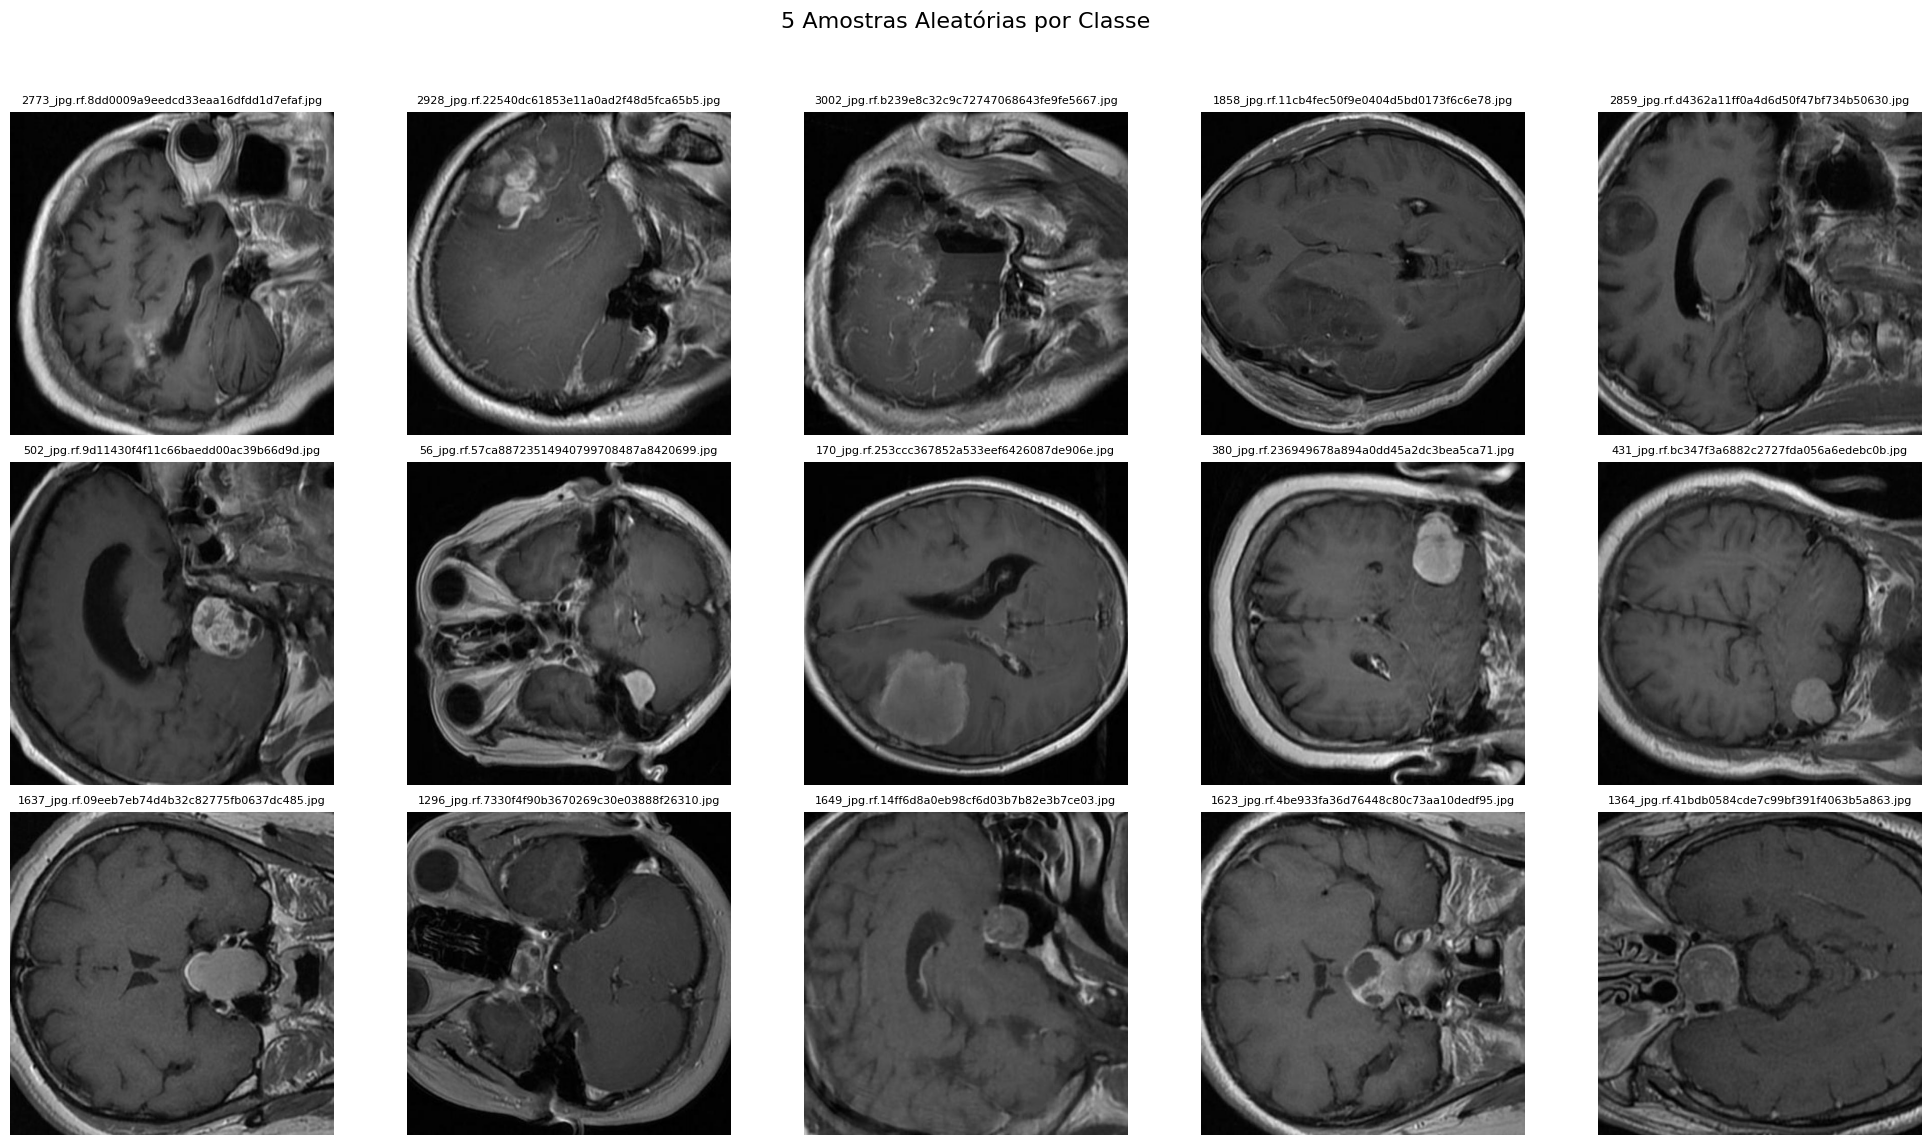

In [ ]:
# Coletar 5 amostras aleatórias de cada classe
samples_per_class = 5
images_to_display = []

for class_name in class_names:
    class_df = metrics_df[metrics_df['class'] == class_name]
    #Garantir que não tentemos amostrar mais imagens do que as disponíveis
    num_samples = min(samples_per_class, len(class_df))
    if num_samples > 0:
        sample_paths = random.sample(class_df['path'].tolist(), num_samples)
        images_to_display.extend(sample_paths)

display_image_grid(images_to_display, '5 Amostras Aleatórias por Classe', len(class_names), samples_per_class)

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Aumenta o dataset horizontalmente
    transforms.ToTensor(), # Converte a imagem para um tensor PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normaliza
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_valid = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Carrega os datasets usando ImageFolder
try:
    train_dataset = datasets.ImageFolder(imagefolder_train_path, transform=transform_train)
    test_dataset = datasets.ImageFolder(imagefolder_test_path, transform=transform_test)
    valid_dataset = datasets.ImageFolder(imagefolder_valid_path, transform=transform_valid)

    print(f"Número de imagens de treino: {len(train_dataset)}")
    print(f"Número de imagens de teste: {len(test_dataset)}")
    print(f"Classes encontradas: {train_dataset.classes}")

    # Cria DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    print(f"\nPrimeiro batch do DataLoader de treino: {next(iter(train_loader))[0].shape}")

except Exception as e:
    print(f"Erro ao carregar o dataset com ImageFolder: {e}")
    print("Verifique se a estrutura de pastas está correta (ex: seu_dataset/dataset_processed/train/classe1/img.jpg).")
    print("Caminho do diretório de treino esperado:", imagefolder_train_path)
    print("Caminho do diretório de teste esperado:", imagefolder_test_path)
    print("Caminho do diretório de validação esperado:", imagefolder_valid_path)


Número de imagens de treino: 2144
Número de imagens de teste: 308
Classes encontradas: ['glioma', 'meningioma', 'pituitary']

Primeiro batch do DataLoader de treino: torch.Size([32, 3, 640, 640])


##### 3.5 Identificação de Outliers por Método Estatístico (IQR)

In [ ]:
# Métricas para verificar outliers
metrics_to_check = ['width', 'height'] # Removido 'brightness' e 'contrast' por não estarem no metrics_df

all_outlier_images = pd.DataFrame()

print("Detectando outliers nas seguintes métricas usando o método IQR:")
for metric in metrics_to_check:
    outliers_df, lower_bound, upper_bound = detect_outliers_iqr(metrics_df, metric)
    if not outliers_df.empty:
        print(f"  - Métrica '{metric}': {len(outliers_df)} outliers encontrados (Limite Inferior: {lower_bound:.2f}, Limite Superior: {upper_bound:.2f})")
        # Adicionar uma coluna indicando por qual métrica a imagem é um outlier
        outliers_df['outlier_metric'] = metric
        all_outlier_images = pd.concat([all_outlier_images, outliers_df])
    else:
        print(f"  - Métrica '{metric}': Nenhum outlier encontrado.")

# Remover duplicatas, pois uma imagem pode ser outlier em múltiplas métricas
all_outlier_images = all_outlier_images.drop_duplicates(subset=['path']).reset_index(drop=True)

print(f"\nTotal de imagens identificadas como potenciais outliers: {len(all_outlier_images)}")
display(all_outlier_images.head())

Detectando outliers nas seguintes métricas usando o método IQR:
  - Métrica 'width': Nenhum outlier encontrado.
  - Métrica 'height': Nenhum outlier encontrado.

Total de imagens identificadas como potenciais outliers: 0


""


##### 3.6 Visualização de Amostras de Outliers Identificados

Vamos exibir algumas das imagens identificadas como potenciais outliers para uma inspeção visual.

In [ ]:
if not all_outlier_images.empty:
    # Selecionar até 10 imagens aleatórias dos outliers para visualização
    num_samples_to_show = min(15, len(all_outlier_images))
    sample_outlier_paths = random.sample(all_outlier_images['path'].tolist(), num_samples_to_show)

    plt.figure(figsize=(num_samples_to_show * 3, 5))
    plt.suptitle('Amostras de Imagens Identificadas como Outliers (IQR)', fontsize=16)

    for i, img_path in enumerate(sample_outlier_paths):
        plt.subplot(1, num_samples_to_show, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        # Encontrar a métrica que classificou esta imagem como outlier para o título
        outlier_info = all_outlier_images[all_outlier_images['path'] == img_path].iloc[0]
        title_text = f"{os.path.basename(img_path)}\n(Outlier por: {outlier_info['outlier_metric']})"
        plt.title(title_text, fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Nenhuma imagem identificada como outlier pelo método IQR para visualização.")

Nenhuma imagem identificada como outlier pelo método IQR para visualização.


##Treinamento do dataset


### Configuração do Modelo ResNet e Treinamento

Vamos utilizar um modelo ResNet pré-treinado do `torchvision` e adaptá-lo para a nossa tarefa de classificação de imagens de tumores cerebrais. Em seguida, configuraremos o otimizador, a função de perda e o loop de treinamento e validação.

In [ ]:
# Determina o número de classes a partir do dataset de treino
num_classes = len(train_dataset.classes)
print(f"Número de classes detectadas: {num_classes}")

# Carrega um modelo ResNet pré-treinado (e.g., ResNet18)
# model = models.resnet18(pretrained=True)
# Para PyTorch 1.10+, 'pretrained' foi substituído por 'weights'
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congela todos os parâmetros do modelo pré-treinado
for param in model.parameters():
    param.requires_grad = False

# Substitui a camada final totalmente conectada para a nossa tarefa de classificação
# A ResNet18 tem uma camada 'fc' (fully connected) no final
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Define o dispositivo de execução (GPU se disponível, caso contrário CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define a função de perda e o otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Apenas os parâmetros da nova camada 'fc' serão treinados

Número de classes detectadas: 3


### Loop de Treinamento e Validação

Agora vamos implementar o loop principal de treinamento do modelo, incluindo a fase de validação para monitorar o desempenho e evitar overfitting.

In [ ]:
num_epochs = 100 # Você pode ajustar o número de épocas

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

print("Iniciando o treinamento...")

for epoch in range(num_epochs):
    model.train() # Define o modelo para o modo de treinamento
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Treino]"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zera os gradientes

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Fase de Validação
    model.eval() # Define o modelo para o modo de avaliação
    running_loss_valid = 0.0
    correct_valid = 0
    total_valid = 0

    with torch.no_grad(): # Desativa o cálculo de gradientes
        for inputs_valid, labels_valid in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validação]"):
            inputs_valid, labels_valid = inputs_valid.to(device), labels_valid.to(device)

            outputs_valid = model(inputs_valid)
            loss_valid = criterion(outputs_valid, labels_valid)

            running_loss_valid += loss_valid.item() * inputs_valid.size(0)
            _, predicted_valid = torch.max(outputs_valid.data, 1)
            total_valid += labels_valid.size(0)
            correct_valid += (predicted_valid == labels_valid).sum().item()

    epoch_valid_loss = running_loss_valid / len(valid_loader.dataset)
    epoch_valid_accuracy = correct_valid / total_valid
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Treino Loss: {epoch_train_loss:.4f}, Treino Acc: {epoch_train_accuracy:.4f} - "
          f"Validação Loss: {epoch_valid_loss:.4f}, Validação Acc: {epoch_valid_accuracy:.4f}")

print("Treinamento concluído!")

Iniciando o treinamento...


Epoch 1/100 [Validação]: 100%|██████████| 20/20 [00:10<00:00,  1.94it/s]


Epoch 1/100 - Treino Loss: 0.8447, Treino Acc: 0.6241 - Validação Loss: 0.9241, Validação Acc: 0.5621


Epoch 2/100 [Validação]: 100%|██████████| 20/20 [00:10<00:00,  1.96it/s]


Epoch 2/100 - Treino Loss: 0.6149, Treino Acc: 0.7612 - Validação Loss: 0.6654, Validação Acc: 0.6650


...

Epoch 62/100 [Validação]: 100%|██████████| 20/20 [00:09<00:00,  2.01it/s]


Epoch 62/100 - Treino Loss: 0.2555, Treino Acc: 0.9021 - Validação Loss: 0.2785, Validação Acc: 0.8938


Epoch 63/100 [Validação]: 100%|██████████| 20/20 [00:09<00:00,  2.09it/s]


Epoch 63/100 - Treino Loss: 0.2632, Treino Acc: 0.8965 - Validação Loss: 0.2893, Validação Acc: 0.8905


Epoch 64/100 [Treino]:   6%|▌         | 4/67 [00:02<00:38,  1.63it/s]

### Avaliação do Modelo

Após o treinamento, vamos avaliar o desempenho do modelo nos conjuntos de treino e validação usando o relatório de classificação e a matriz de confusão.

In [ ]:
# Função para obter predições e labels verdadeiros
def get_predictions_and_labels(loader, model, device):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Coletando Predições"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

class_names = train_dataset.classes # Pega os nomes das classes do dataset de treino

#### Avaliação no Conjunto de Treino

In [ ]:
train_labels, train_preds = get_predictions_and_labels(train_loader, model, device)

print("\n--- Relatório de Classificação (Treino) ---")
print(classification_report(train_labels, train_preds, target_names=class_names))

# Matriz de Confusão para o Treino
cm_train = confusion_matrix(train_labels, train_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Treino)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

#### Avaliação no Conjunto de Validação

In [ ]:
valid_labels, valid_preds = get_predictions_and_labels(valid_loader, model, device)

print("\n--- Relatório de Classificação (Validação) ---")
print(classification_report(valid_labels, valid_preds, target_names=class_names))

# Matriz de Confusão para a Validação
cm_valid = confusion_matrix(valid_labels, valid_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Validação)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

## Fine-Tuning do Modelo

Agora que o modelo foi treinado com as camadas de feature extraction congeladas, podemos realizar o fine-tuning. Nesta etapa, vamos descongelar as últimas camadas convolucionais do modelo pré-treinado e retreiná-las com uma taxa de aprendizado menor para que o modelo possa ajustar os pesos para a tarefa específica.

In [ ]:
print("Preparando para Fine-Tuning...")

# Descongela as últimas camadas (por exemplo, a layer4 e a camada FC)
# ResNet18 tem 4 blocos de camadas (layer1, layer2, layer3, layer4)
# Vamos descongelar a última camada convolucional (layer4) e a camada FC

# Primeiro, garanta que o modelo está novamente no dispositivo correto (GPU/CPU)
model = model.to(device)

# Descongelar a camada 'fc' (já fizemos antes, mas reconfirmando para clareza)
for param in model.fc.parameters():
    param.requires_grad = True

# Descongelar a 'layer4' e 'layer3' (e seus submódulos)
# Você pode ajustar quantas camadas deseja descongelar
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.layer3.parameters(): # Descongelando também a layer3
    param.requires_grad = True

# Defina um otimizador com uma taxa de aprendizado menor para o fine-tuning
# Usaremos SGD ou Adam com uma LR menor para evitar grandes alterações nos pesos pré-treinados

# Otimizador que inclui os parâmetros das camadas descongeladas e da camada FC
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

# A função de perda permanece a mesma
criterion_ft = nn.CrossEntropyLoss()

print("Modelo configurado para Fine-Tuning. Camadas descongeladas e otimizador atualizado.")

### Loop de Treinamento para Fine-Tuning

Agora vamos executar o loop de treinamento para o fine-tuning. É importante monitorar de perto as métricas para evitar overfitting, pois estamos treinando mais parâmetros.

In [ ]:
num_epochs_ft = 10 # Número de épocas para o fine-tuning, geralmente menor que o treinamento inicial

# Initialize lists to store metrics for each of the 5 runs
all_final_valid_losses_ft = []
all_final_valid_accuracies_ft = []

for i in range(5):
  print(f"\n--- Iniciando Rodada {i+1} de Fine-Tuning ---")

  # Reset model parameters if fine-tuning is supposed to start fresh each time
  # For now, assuming it continues fine-tuning from the previous state of the model.
  # If a fresh start is needed, model and optimizer should be re-initialized here.

  for epoch_ft in range(num_epochs_ft):
      model.train() # Define o modelo para o modo de treinamento
      running_loss_ft = 0.0
      correct_train_ft = 0
      total_train_ft = 0

      for inputs, labels in tqdm(train_loader, desc=f"Rodada {i+1} | Epoch FT {epoch_ft+1}/{num_epochs_ft} [Treino]"):
          inputs, labels = inputs.to(device), labels.to(device)

          optimizer_ft.zero_grad()

          outputs = model(inputs)
          loss = criterion_ft(outputs, labels)
          loss.backward()
          optimizer_ft.step()

          running_loss_ft += loss.item() * inputs.size(0)
          _, predicted = torch.max(outputs.data, 1)
          total_train_ft += labels.size(0)
          correct_train_ft += (predicted == labels).sum().item()

      epoch_train_loss_ft = running_loss_ft / len(train_loader.dataset)
      epoch_train_accuracy_ft = correct_train_ft / total_train_ft

      # Fase de Validação (usando o mesmo valid_loader e lógica)
      model.eval() # Define o modelo para o modo de avaliação
      running_loss_valid_ft = 0.0
      correct_valid_ft = 0
      total_valid_ft = 0

      with torch.no_grad():
          for inputs_valid, labels_valid in tqdm(valid_loader, desc=f"Rodada {i+1} | Epoch FT {epoch_ft+1}/{num_epochs_ft} [Validação]"):
              inputs_valid, labels_valid = inputs_valid.to(device), labels_valid.to(device)

              outputs_valid = model(inputs_valid)
              loss_valid = criterion_ft(outputs_valid, labels_valid)

              running_loss_valid_ft += loss_valid.item() * inputs_valid.size(0)
              _, predicted_valid = torch.max(outputs_valid.data, 1)
              total_valid_ft += labels_valid.size(0)
              correct_valid_ft += (predicted_valid == labels_valid).sum().item()

      epoch_valid_loss_ft = running_loss_valid_ft / len(valid_loader.dataset)
      epoch_valid_accuracy_ft = correct_valid_ft / total_valid_ft

      print(f"Rodada {i+1} | Epoch FT {epoch_ft+1}/{num_epochs_ft} - "
            f"Treino Loss FT: {epoch_train_loss_ft:.4f}, Treino Acc FT: {epoch_train_accuracy_ft:.4f} - "
            f"Validação Loss FT: {epoch_valid_loss_ft:.4f}, Validação Acc FT: {epoch_valid_accuracy_ft:.4f}")

  # Store the final validation loss and accuracy for this run
  all_final_valid_losses_ft.append(epoch_valid_loss_ft)
  all_final_valid_accuracies_ft.append(epoch_valid_accuracy_ft)
  print(f"--- Rodada {i+1} de Fine-Tuning Concluída! ---")

print("\nTodos os ciclos de Fine-Tuning concluídos!")

In [ ]:
print(f"\n--- Análise Final do Desempenho do Fine-Tuning ({len(all_final_valid_accuracies_ft)} Rodadas) ---")
print(f"Média da Acurácia de Validação: {np.mean(all_final_valid_accuracies_ft):.4f}")
print(f"Desvio Padrão da Acurácia de Validação: {np.std(all_final_valid_accuracies_ft):.4f}")
print(f"Média do Loss de Validação: {np.mean(all_final_valid_losses_ft):.4f}")
print(f"Desvio Padrão do Loss de Validação: {np.std(all_final_valid_losses_ft):.4f}")

### Avaliação do Modelo (Pós Fine-Tuning)

Após o fine-tuning, vamos reavaliar o desempenho do modelo nos conjuntos de treino e validação para verificar as melhorias.

#### Avaliação no Conjunto de Treino (Pós Fine-Tuning)

In [ ]:
train_labels_ft, train_preds_ft = get_predictions_and_labels(train_loader, model, device)

print("\n--- Relatório de Classificação (Treino - Pós Fine-Tuning) ---")
print(classification_report(train_labels_ft, train_preds_ft, target_names=class_names))

# Matriz de Confusão para o Treino (Pós Fine-Tuning)
cm_train_ft = confusion_matrix(train_labels_ft, train_preds_ft)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train_ft, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Treino - Pós Fine-Tuning)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

#### Avaliação no Conjunto de Validação (Pós Fine-Tuning)

In [ ]:
valid_labels_ft, valid_preds_ft = get_predictions_and_labels(valid_loader, model, device)

print("\n--- Relatório de Classificação (Validação - Pós Fine-Tuning) ---")
print(classification_report(valid_labels_ft, valid_preds_ft, target_names=class_names))

# Matriz de Confusão para a Validação (Pós Fine-Tuning)
cm_valid_ft = confusion_matrix(valid_labels_ft, valid_preds_ft)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_valid_ft, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Validação - Pós Fine-Tuning)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

## Visualização da Região do Tumor com Grad-CAM

Para entender quais partes da imagem o modelo está usando para fazer suas previsões, utilizaremos a técnica Grad-CAM (Gradient-weighted Class Activation Mapping). Esta técnica gera mapas de calor que destacam as regiões mais importantes da imagem para a classificação de uma determinada classe.

In [ ]:
# Instala a biblioteca pytorch-grad-cam
!pip install pytorch-grad-cam --quiet

# Importa as bibliotecas necessárias para Grad-CAM
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Bibliotecas Grad-CAM instaladas e importadas com sucesso!")

### Preparação para Grad-CAM

Precisamos definir a camada alvo (target layer) do nosso modelo para que o Grad-CAM possa calcular os gradientes corretamente. Para ResNet18, a última camada convolucional é `model.layer4[-1]`.

In [ ]:
# Define a camada alvo para o Grad-CAM
# Para ResNet18, a última camada convolucional geralmente é a última camada do último bloco (layer4)
target_layer = model.layer4[-1]

# Inicializa o Grad-CAM
# Você pode experimentar com outros métodos de CAM como HiResCAM, GradCAMPlusPlus, etc.
# cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=torch.cuda.is_available())
cam = HiResCAM(model=model, target_layers=[target_layer], use_cuda=torch.cuda.is_available())

print(f"Grad-CAM configurado com a camada alvo: {target_layer}")

### Geração e Visualização de Mapas de Calor Grad-CAM

Vamos selecionar algumas imagens do conjunto de teste, aplicar o Grad-CAM e visualizar os mapas de calor sobrepostos às imagens originais. Isso nos mostrará as regiões da imagem que mais influenciaram a decisão do modelo.

In [ ]:
def visualize_grad_cam(model, image_path, true_label, predicted_label, cam_algorithm, class_names, device):
    # Carrega e pré-processa a imagem
    original_image = Image.open(image_path).convert('RGB')
    # Usar a mesma transformação de validação/teste (sem data augmentation)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(original_image).unsqueeze(0).to(device) # Adiciona dimensão de batch

    # Define o alvo do CAM (a classe predita pelo modelo)
    # Se você quiser visualizar o CAM para uma classe específica (e.g., a classe verdadeira),
    # pode passar [ClassifierOutputTarget(true_label)]
    # Mas para entender o que levou à predição, ClassifierOutputTarget(predicted_label) é mais comum.
    targets = [ClassifierOutputTarget(predicted_label)]

    # Gera o mapa de calor
    # A imagem original para a função show_cam_on_image precisa ser um array numpy de 0-255
    rgb_img = np.array(original_image, dtype=np.float32) / 255
    grayscale_cam = cam_algorithm(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Sobrepõe o mapa de calor à imagem original
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Exibe a imagem
    plt.imshow(cam_image)
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[predicted_label]}", fontsize=10)
    plt.axis('off')

    # Adiciona a informação da doença e região afetada diretamente na imagem
    disease_name = class_names[predicted_label]
    # Placeholder para a região, que deve ser observada visualmente pelo usuário
    region_info = "Região: [Observar no mapa de calor]"

    plt.text(0.02, 0.02, f"Doença: {disease_name}", color='black', fontsize=9, ha='left', va='bottom',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'), transform=plt.gca().transAxes)
    plt.text(0.02, 0.12, region_info, color='black', fontsize=9, ha='left', va='bottom',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'), transform=plt.gca().transAxes)


# Seleciona algumas imagens aleatórias do conjunto de teste
num_samples_to_visualize = 5

# Certifique-se de que test_dataset e class_names estejam disponíveis
if 'test_dataset' in locals() and test_dataset and 'class_names' in locals() and class_names:
    sample_indices = random.sample(range(len(test_dataset)), num_samples_to_visualize)

    plt.figure(figsize=(num_samples_to_visualize * 4, 6))
    plt.suptitle('Grad-CAM: Regiões de Ativação do Modelo', fontsize=16, y=1.02)

    model.eval() # Coloca o modelo em modo de avaliação

    for i, idx in enumerate(sample_indices):
        img_path, true_label = test_dataset.samples[idx]
        input_tensor_pred = test_dataset[idx][0].unsqueeze(0).to(device) # Para fazer a predição

        with torch.no_grad():
            outputs = model(input_tensor_pred)
            _, predicted_label_tensor = torch.max(outputs, 1)
            predicted_label = predicted_label_tensor.item()

        plt.subplot(1, num_samples_to_visualize, i + 1)
        visualize_grad_cam(model, img_path, true_label, predicted_label, cam, class_names, device)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("Não foi possível carregar o test_dataset ou as class_names para visualização do Grad-CAM.")
    print("Verifique se as células anteriores foram executadas corretamente.")

### Interpretação do Grad-CAM e Análise da Região do Tumor

As imagens acima mostram o mapa de calor do Grad-CAM sobreposto às imagens originais. As áreas em vermelho/amarelo indicam as regiões da imagem que mais contribuíram para a predição da classe feita pelo modelo.

Para cada imagem, você pode observar a:
*   **Doença Predita:** Indicada na legenda da imagem (`Pred: [Classe]`).
*   **Região Afetada:** O texto `Região: [Observar no mapa de calor]` serve como um prompt para você analisar visualmente onde o mapa de calor está mais concentrado e descrever a área do cérebro correspondente. Por exemplo, se o calor estiver na parte superior esquerda, você pode inferir que a anomalia está nessa região.

**Como personalizar os comentários na imagem:**

Se você tiver insights mais específicos ou quiser adicionar detalhes para cada imagem (ex: "Região: Lóbulo frontal esquerdo"), você pode editar a função `visualize_grad_cam` na célula anterior (`eb049372`). Você pode, por exemplo, criar um dicionário de descrições de região por classe ou por imagem, e usar isso na função para tornar os comentários mais precisos.